# Candidate Discovery, Step By Step

This notebook teaches the candidate-discovery workflow behind the project.

The goal is to answer a simple but important research-design question:

> Before we build a model, how do we know that our target and predictor variables were not chosen arbitrarily?

We solve this by building two catalogs:

1. `target_candidate_catalog.csv`: a systematic screen of possible OECD patent target variables.
2. `predictor_candidate_catalog.csv`: a literature- and database-driven screen of possible predictor variables.

This is still **not modeling**. It is the evidence trail that justifies which variables are worth modeling later.

## The Big Picture

A beginner mistake is to download a few variables, merge them, and immediately train a model. That is risky because we may miss obvious candidates or include variables that look convenient but are hard to defend.

This notebook uses a slower but cleaner workflow:

```text
Research question
      |
      v
OECD patent metadata ---------------------> target candidate catalog
      |                                             |
      |                                             v
Existing coverage checks              main / robustness / mechanism / context candidates

Literature notes + database metadata ------> predictor candidate catalog
      |                                             |
      |                                             v
Coverage + measurement caveats       include / optional / defer / drop
```

The key idea is that metadata comes before modeling. We first learn what the databases offer, then choose a small interpretable set.

## Optional Google Colab Setup

Run the next cell only when opening this notebook in Google Colab. In local Jupyter, the cell detects that it is not in Colab and safely skips itself.

In [ ]:
# Optional: run this cell only when using Google Colab.
import importlib.util
import os
import subprocess
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    REPO_URL = "https://github.com/songjie1025/env-innovation-prediction.git"
    REPO_DIR = Path("/content/env-innovation-prediction")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(["python", "-m", "pip", "install", "-r", "requirements.txt"], check=True)
else:
    print("Local environment detected; skipping Colab setup.")

## 1. Load The Project Tools

The reusable logic lives in `2_data/scripts/candidate_discovery.py`.

The notebook imports that script instead of copying the same logic. This matters because notebooks are good for explanation, while scripts are better for reproducible data processing.

In [1]:
from pathlib import Path
import sys

from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "2_data" / "scripts").exists():
            return candidate
    for child in start.glob("*/README.md"):
        candidate = child.parent
        if (candidate / "2_data" / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing README.md and 2_data/scripts.")


ROOT = find_project_root(Path.cwd().resolve())
SCRIPT_DIR = ROOT / "2_data" / "scripts"
PROCESSED_DIR = ROOT / "2_data" / "processed"
sys.path.append(str(SCRIPT_DIR))

from candidate_discovery import run_candidate_discovery

pd.set_option("display.max_colwidth", 120)
ROOT

PosixPath('/Users/marcjin/Desktop/Studium/Master/26SS/env-innovation-prediction')

## 2. Load Or Regenerate The Catalogs

By default, this notebook reads the committed catalog files from `2_data/processed/`.

Set `RUN_DISCOVERY = True` only when you want to regenerate the catalogs. The default run does not download all time series. Optional World Bank metadata scanning is off unless explicitly enabled.

In [2]:
RUN_DISCOVERY = False
SCAN_WORLD_BANK_METADATA = False

required_outputs = {
    "targets": PROCESSED_DIR / "target_candidate_catalog.csv",
    "predictors": PROCESSED_DIR / "predictor_candidate_catalog.csv",
    "summary": PROCESSED_DIR / "candidate_discovery_summary.md",
}

if RUN_DISCOVERY or not all(path.exists() for path in required_outputs.values()):
    target_catalog, predictor_catalog = run_candidate_discovery(
        scan_world_bank=SCAN_WORLD_BANK_METADATA,
        output_dir=PROCESSED_DIR,
    )
else:
    target_catalog = pd.read_csv(required_outputs["targets"])
    predictor_catalog = pd.read_csv(required_outputs["predictors"])

pd.DataFrame(
    {
        "catalog": ["target candidates", "predictor candidates"],
        "rows": [len(target_catalog), len(predictor_catalog)],
        "columns": [target_catalog.shape[1], predictor_catalog.shape[1]],
    }
)

,catalog,rows,columns
0,target candidates,2688,25
1,predictor candidates,13,16


## 3. Check The Input Files

The discovery step depends on existing metadata and first-pass coverage checks.

For a beginner, this is the first reproducibility habit: before transforming data, check that the expected inputs are present and know what each one does.

In [3]:
input_files = pd.DataFrame(
    [
        {
            "file": "oecd_patent_dimension_values.csv",
            "why_we_need_it": "Lists valid OECD patent dimensions such as UNIT_MEASURE, TYPE, TECH, and PAT.",
            "path": PROCESSED_DIR / "oecd_patent_dimension_values.csv",
        },
        {
            "file": "data_availability.csv",
            "why_we_need_it": "Stores first-pass coverage checks for variables already downloaded.",
            "path": PROCESSED_DIR / "data_availability.csv",
        },
        {
            "file": "review_synthesis.md",
            "why_we_need_it": "Summarizes literature-based reasoning for target and predictor concepts.",
            "path": ROOT / "1_literature_review" / "review_synthesis.md",
        },
        {
            "file": "variable_framework.md",
            "why_we_need_it": "Connects the research question to candidate predictor groups.",
            "path": ROOT / "1_literature_review" / "variable_framework.md",
        },
    ]
)
input_files["exists"] = input_files["path"].map(lambda path: path.exists())
display(input_files[["file", "exists", "why_we_need_it"]])

,file,exists,why_we_need_it
0,oecd_patent_dimension_values.csv,True,"Lists valid OECD patent dimensions such as UNIT_MEASURE, TYPE, TECH, and PAT."
1,data_availability.csv,True,Stores first-pass coverage checks for variables already downloaded.
2,review_synthesis.md,True,Summarizes literature-based reasoning for target and predictor concepts.
3,variable_framework.md,True,Connects the research question to candidate predictor groups.


## 4. Understand The OECD Patent Code Structure

OECD patent variables are not single names. They are combinations of dimensions.

For this dataflow, a source variable has this structure:

```text
UNIT_MEASURE.TYPE.TECH.PAT
```

Example:

```text
PT_INV.DEV.ENV_PAT._Z
```

This means:

| Part | Meaning |
|---|---|
| `PT_INV` | Percentage of inventions |
| `DEV` | Development of environment-related technologies |
| `ENV_PAT` | Overall environment-related technologies |
| `_Z` | No regional patent-office breakdown |

So candidate discovery starts by reading the available dimension codes instead of guessing variable names by hand.

In [4]:
dimension_values = pd.read_csv(PROCESSED_DIR / "oecd_patent_dimension_values.csv")

dimension_summary = (
    dimension_values.groupby(["dimension", "dimension_label"], as_index=False)
    .agg(available_codes=("code", "count"))
    .sort_values("dimension")
)
display(dimension_summary)

for dimension in ["UNIT_MEASURE", "TYPE", "TECH", "PAT"]:
    print(f"\n{dimension}")
    display(
        dimension_values.loc[dimension_values["dimension"].eq(dimension), ["code", "label"]]
        .reset_index(drop=True)
    )

,dimension,dimension_label,available_codes
0,PAT,Regional patent office,7
1,TECH,Technological domain,12
2,TYPE,Patent counting type,4
3,UNIT_MEASURE,Indicator measure,8



UNIT_MEASURE


,code,label
0,INV_PS,Inventions per person
1,INV_RD_S13,Inventions per unit of government R&D
2,INV_RD_S1ZS,Inventions per unit of public R&D
3,IX,Index
4,PT_INV,Percentage of inventions
5,PT_TECH,Percentage of technologies
6,PT_TECH_COL,Percentage of collaborations in all technologies
7,PT_TECH_ENV,Percentage of environment related technologies



TYPE


,code,label
0,COL,International collaboration in development of environment-related technologies
1,DEV,Development of environment-related technologies
2,DIFF,Diffusion of environment-related technologies
3,RENEW,Development of renewable energy technologies



TECH


,code,label
0,ADAPT,Climate change adaptation technologies
1,BUILD,Climate change mitigation technologies related to buildings
2,ENE,"Climate change mitigation technologies related to energy generation, transmission or distribution"
3,ENV_PAT,Environment-related technologies
4,GHG,"Capture, storage, sequestration or disposal of greenhouse gases"
5,GOODS,Climate change mitigation technologies in the production or processing of goods
6,ICT,Climate change mitigation in information and communication technologies (ICT)
7,MAN,Environmental management
8,OCEAN,Sustainable ocean economy
9,TOT,All technologies (total patents)



PAT


,code,label
0,_Z,Not applicable
1,ARIPO,African Regional Industrial Property Organisation
2,EAPO,Eurasian Patent Organization
3,EPO,European Patent Office
4,GCC,Patent Office of the Cooperation Council for the Arab States of the Gulf
5,OAPI,African Intellectual Property Organization
6,PCT,Patent Cooperation Treaty


## 5. Generate The Target Search Space

Because the OECD target code has four dimensions, the full candidate space is the Cartesian product of the available codes.

That means:

```text
all UNIT_MEASURE choices
x all TYPE choices
x all TECH choices
x all PAT choices
```

In this project, that gives `8 x 4 x 12 x 7 = 2688` possible OECD patent combinations.

We do **not** download all 2688 time series. First, we catalog and classify them.

In [5]:
counts = dimension_values.groupby("dimension")["code"].nunique()
expected_combinations = counts["UNIT_MEASURE"] * counts["TYPE"] * counts["TECH"] * counts["PAT"]

pd.DataFrame(
    {
        "step": ["dimension product", "rows in target catalog"],
        "count": [expected_combinations, len(target_catalog)],
    }
)

,step,count
0,dimension product,2688
1,rows in target catalog,2688


## 6. Apply Target Screening As Research Triage

This is the part where the catalog becomes useful.

The filter is not a simple keep/drop rule. It is a **research triage** rule. A variable can be important and still not be the best main target.

We use two columns:

| Column | Meaning |
|---|---|
| `candidate_role` | What kind of candidate this is. |
| `recommended_use` | How it could be used later. |

The current roles are:

| Role | Meaning |
|---|---|
| `main_target_candidate` | Best fit for the main outcome variable. |
| `secondary_target` | Useful robustness or thematic outcome, but narrower or harder to interpret. |
| `mechanism_candidate` | Important for mechanisms or descriptive analysis, but not the broad outcome. |
| `breakdown_candidate` | Useful diagnostic breakdown, for example patent-office route, but too detailed for the main outcome. |
| `context_only` | Denominator or context variable, useful for interpretation but not itself the outcome. |
| `not_suitable` | Hard to interpret for this project without a separate justification. |

This matters because `include=False` does **not** mean "irrelevant". It often means "do not use as the main target".

,candidate_role,recommended_use,include,candidate_count
2,main_target_candidate,main outcome candidate,True,1
6,secondary_target,robustness outcome candidate,True,1
0,breakdown_candidate,diagnostic breakdown candidate,False,2112
1,context_only,denominator or context variable,False,224
3,mechanism_candidate,mechanism or descriptive candidate,False,198
4,not_suitable,do not use without separate justification,False,12
5,secondary_target,robustness or thematic outcome candidate,False,140


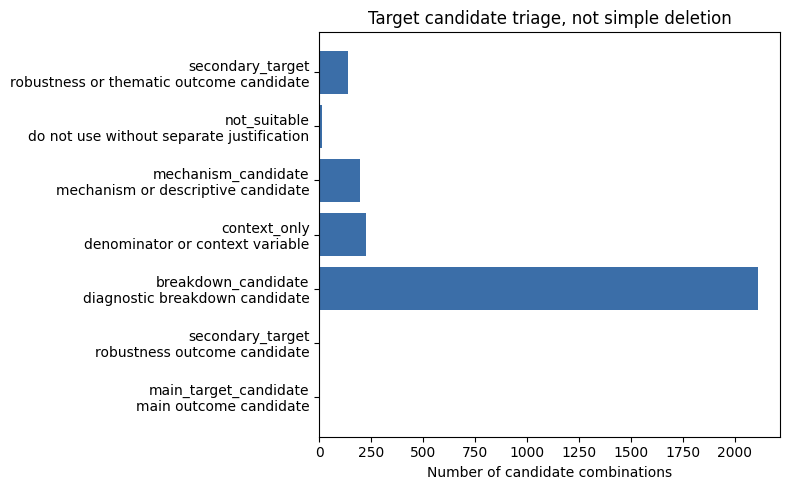

In [6]:
target_use_counts = (
    target_catalog.groupby(["candidate_role", "recommended_use", "include"], as_index=False)
    .size()
    .rename(columns={"size": "candidate_count"})
    .sort_values(["include", "candidate_role", "recommended_use"], ascending=[False, True, True])
)
display(target_use_counts)

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = target_use_counts.assign(
    label=lambda data: data["candidate_role"] + "\n" + data["recommended_use"]
)
ax.barh(plot_data["label"], plot_data["candidate_count"], color="#3b6ea8")
ax.set_title("Target candidate triage, not simple deletion")
ax.set_xlabel("Number of candidate combinations")
ax.set_ylabel("")
plt.tight_layout()

## 7. The Decision Tree In Plain English

The script applies the rules in this order:

1. If `TECH = TOT`, treat it as `context_only` because it is the all-technologies denominator.
2. If `PAT` is not `_Z`, treat it as a `breakdown_candidate` because it is a patent-office route, not the broad country-year outcome.
3. If the variable measures collaboration, treat it as a `mechanism_candidate`.
4. If `TYPE = DIFF`, treat it as a `mechanism_candidate` because diffusion is about spread or adoption, not domestic development.
5. If `TYPE = RENEW`, treat it as a `secondary_target` because renewable energy is important but narrower than all environment-related technologies.
6. If the variable is broad `DEV.ENV_PAT._Z`, evaluate whether its unit is interpretable enough for the main outcome.
7. If it is a broad subdomain such as energy or transport, keep it as a `secondary_target`.

This is why collaboration, diffusion, and renewable energy are not thrown away. They are kept in the catalog with a different recommended use.

In [7]:
example_codes = [
    "PT_INV.DEV.ENV_PAT._Z",
    "INV_PS.DEV.ENV_PAT._Z",
    "PT_TECH.DEV.ENV_PAT._Z",
    "PT_INV.RENEW.ENV_PAT._Z",
    "PT_INV.DIFF.ENV_PAT._Z",
    "PT_TECH_COL.COL.ENV_PAT._Z",
    "PT_INV.DEV.ENV_PAT.EPO",
    "PT_INV.DEV.TOT._Z",
]

examples = target_catalog.loc[
    target_catalog["source_variable"].isin(example_codes),
    [
        "source_variable",
        "candidate_role",
        "recommended_use",
        "include",
        "reason",
    ],
].sort_values("source_variable")

display(examples.reset_index(drop=True))

,source_variable,candidate_role,recommended_use,include,reason
0,INV_PS.DEV.ENV_PAT._Z,secondary_target,robustness outcome candidate,True,Size-normalized patent intensity candidate; useful robustness target.
1,PT_INV.DEV.ENV_PAT.EPO,breakdown_candidate,diagnostic breakdown candidate,False,"Patent-office breakdown may help diagnose regional patenting routes, but it is too narrow for the main country-year ..."
2,PT_INV.DEV.ENV_PAT._Z,main_target_candidate,main outcome candidate,True,Preferred normalized target: environment-related technologies as a share of inventions.
3,PT_INV.DEV.TOT._Z,context_only,denominator or context variable,False,All-technologies denominator; useful context for normalization but not an environment-related innovation outcome.
4,PT_INV.DIFF.ENV_PAT._Z,mechanism_candidate,mechanism or descriptive candidate,False,"Diffusion is relevant for adoption and international spread of environmental technologies, but it is analytically di..."
5,PT_INV.RENEW.ENV_PAT._Z,secondary_target,robustness or thematic outcome candidate,False,Renewable-energy patenting is substantively important but narrower than the broad environmental-innovation target.
6,PT_TECH.DEV.ENV_PAT._Z,secondary_target,robustness or thematic outcome candidate,False,Technology-share candidate kept for robustness only because values can be hard to interpret.
7,PT_TECH_COL.COL.ENV_PAT._Z,mechanism_candidate,mechanism or descriptive candidate,False,"International collaboration is relevant for mechanisms and descriptive analysis, but it is not the broad country-yea..."


## 8. Inspect The Leading Target Candidates

Now we look only at the candidates that survive the main screen.

This is not yet a final target decision. It is the shortlist we can defend in front of a reviewer.

In [8]:
leading_target_columns = [
    "source_variable",
    "unit_measure_label",
    "type_label",
    "technology_domain_label",
    "candidate_role",
    "recommended_use",
    "include",
    "coverage_checked",
    "countries_with_data",
    "first_year",
    "last_year",
    "reason",
]

leading_targets = target_catalog.loc[target_catalog["include"], leading_target_columns]
display(leading_targets.reset_index(drop=True))

,source_variable,unit_measure_label,type_label,technology_domain_label,candidate_role,recommended_use,include,coverage_checked,countries_with_data,first_year,last_year,reason
0,PT_INV.DEV.ENV_PAT._Z,Percentage of inventions,Development of environment-related technologies,Environment-related technologies,main_target_candidate,main outcome candidate,True,True,202.0,1990.0,2023.0,Preferred normalized target: environment-related technologies as a share of inventions.
1,INV_PS.DEV.ENV_PAT._Z,Inventions per person,Development of environment-related technologies,Environment-related technologies,secondary_target,robustness outcome candidate,True,True,196.0,1990.0,2023.0,Size-normalized patent intensity candidate; useful robustness target.


## 9. Inspect Important Non-Main Candidates

This table is deliberately included because it is easy to misread a filter.

These variables are not selected as the main target, but they can still be useful for mechanisms, descriptive analysis, or robustness checks.

In [9]:
non_main_examples = (
    target_catalog.loc[
        target_catalog["candidate_role"].isin(["mechanism_candidate", "secondary_target", "breakdown_candidate", "context_only"]),
        [
            "source_variable",
            "candidate_role",
            "recommended_use",
            "include",
            "reason",
        ],
    ]
    .drop_duplicates(["candidate_role", "recommended_use", "reason"])
    .head(12)
    .reset_index(drop=True)
)
display(non_main_examples)

,source_variable,candidate_role,recommended_use,include,reason
0,INV_PS.DEV.ENV_PAT._Z,secondary_target,robustness outcome candidate,True,Size-normalized patent intensity candidate; useful robustness target.
1,INV_PS.DEV.ADAPT._Z,secondary_target,robustness or thematic outcome candidate,False,Broad environmental subdomain; useful for descriptive checks but too narrow for the main target.
2,INV_PS.RENEW.ADAPT._Z,secondary_target,robustness or thematic outcome candidate,False,Renewable-energy patenting is substantively important but narrower than the broad environmental-innovation target.
3,INV_RD_S13.DEV.ENV_PAT._Z,secondary_target,robustness or thematic outcome candidate,False,"R&D-normalized patent intensity may be useful for robustness, but the denominator is harder to compare broadly."
4,PT_TECH.DEV.ENV_PAT._Z,secondary_target,robustness or thematic outcome candidate,False,Technology-share candidate kept for robustness only because values can be hard to interpret.
5,INV_PS.COL.ADAPT._Z,mechanism_candidate,mechanism or descriptive candidate,False,"International collaboration is relevant for mechanisms and descriptive analysis, but it is not the broad country-yea..."
6,INV_PS.DIFF.ADAPT._Z,mechanism_candidate,mechanism or descriptive candidate,False,"Diffusion is relevant for adoption and international spread of environmental technologies, but it is analytically di..."
7,INV_PS.COL.ADAPT.ARIPO,breakdown_candidate,diagnostic breakdown candidate,False,"Patent-office breakdown may help diagnose regional patenting routes, but it is too narrow for the main country-year ..."
8,INV_PS.COL.TOT.ARIPO,context_only,denominator or context variable,False,All-technologies denominator; useful context for normalization but not an environment-related innovation outcome.


## 10. Understand Coverage Checks

`coverage_checked` means that we already downloaded that exact source variable during first-pass exploration and can report observed countries and years.

It does **not** mean every untested candidate has no data. It means we have not spent download effort on it yet. That distinction is important: metadata screening is cheap; full coverage checking is more expensive.

In [10]:
coverage_summary = (
    target_catalog.groupby(["candidate_role", "coverage_checked"], as_index=False)
    .size()
    .rename(columns={"size": "candidate_count"})
    .sort_values(["candidate_role", "coverage_checked"])
)
display(coverage_summary)

checked_targets = target_catalog.loc[target_catalog["coverage_checked"], [
    "source_variable",
    "candidate_role",
    "recommended_use",
    "include",
    "non_missing_observations",
    "countries_with_data",
    "years_with_data",
    "first_year",
    "last_year",
    "reason",
]]
display(checked_targets.reset_index(drop=True))

,candidate_role,coverage_checked,candidate_count
0,breakdown_candidate,False,2112
1,context_only,False,224
2,main_target_candidate,True,1
3,mechanism_candidate,False,198
4,not_suitable,False,12
5,secondary_target,False,139
6,secondary_target,True,2


,source_variable,candidate_role,recommended_use,include,non_missing_observations,countries_with_data,years_with_data,first_year,last_year,reason
0,PT_INV.DEV.ENV_PAT._Z,main_target_candidate,main outcome candidate,True,3538.0,202.0,34.0,1990.0,2023.0,Preferred normalized target: environment-related technologies as a share of inventions.
1,INV_PS.DEV.ENV_PAT._Z,secondary_target,robustness outcome candidate,True,3528.0,196.0,34.0,1990.0,2023.0,Size-normalized patent intensity candidate; useful robustness target.
2,PT_TECH.DEV.ENV_PAT._Z,secondary_target,robustness or thematic outcome candidate,False,3538.0,202.0,34.0,1990.0,2023.0,Technology-share candidate kept for robustness only because values can be hard to interpret.


## 11. Build Predictor Candidates Differently

Predictors are harder than targets because World Bank, OECD, and RISE contain many possible variables.

So the predictor catalog combines two discovery logics:

1. **Literature-driven discovery**: What concepts do papers repeatedly use or recommend?
2. **Database-driven discovery**: Which public indicators can approximate those concepts, and have we checked coverage?

The goal is not to use many predictors. The goal is to avoid missing obvious candidates before choosing a small model.

Important status note: this predictor catalog is provisional. The literature review is not finished yet, so these rows should be read as a structured search record, not the final list of variables for the model.

In [11]:
predictor_columns = [
    "variable_concept",
    "candidate_indicator",
    "source",
    "source_variable",
    "literature_support",
    "expected_direction",
    "coverage_checked",
    "coverage_summary",
    "already_downloaded",
    "include_decision",
]

display(predictor_catalog[predictor_columns])

,variable_concept,candidate_indicator,source,source_variable,literature_support,expected_direction,coverage_checked,coverage_summary,already_downloaded,include_decision
0,GDP per capita,gdp_per_capita,World Bank WDI,NY.GDP.PCAP.KD,Moderate; used as a development and innovation-capacity control.,Positive,True,"gdp_per_capita: 213 countries, 35 years, 1990-2024",True,candidate
1,GDP/population/market size,gdp; population,World Bank WDI,NY.GDP.MKTP.KD; SP.POP.TOTL,Moderate; patent studies often control for market size or total demand.,Positive,True,"gdp: 213 countries, 35 years, 1990-2024; population: 217 countries, 35 years, 1990-2024",True,candidate_control
2,Manufacturing share,manufacturing_share,World Bank WDI,NV.IND.MANF.ZS,"Moderate to weak; sectoral structure matters, but country-level share is coarse.",Ambiguous,True,"manufacturing_share: 203 countries, 35 years, 1990-2024",True,optional
3,R&D expenditure,rd_expenditure_gdp,World Bank WDI,GB.XPD.RSDV.GD.ZS,Strong; repeatedly linked to patenting and environmental innovation capacity.,Positive,True,"rd_expenditure_gdp: 156 countries, 29 years, 1996-2024",True,candidate
4,Researchers,researchers_per_million,World Bank WDI,SP.POP.SCIE.RD.P6,Moderate; conceptually aligned with innovation capacity.,Positive,True,"researchers_per_million: 145 countries, 29 years, 1996-2024",True,secondary_candidate
5,Tertiary education,tertiary_enrollment,World Bank WDI or OECD education data,NaN,Moderate to weak for this specific country-level patent design.,Positive,False,not checked,False,optional
6,Renewable energy share,renewable_energy_share,World Bank WDI,EG.FEC.RNEW.ZS,"Moderate; related literature often uses renewable policies, prices, or capacity.",Positive,True,"renewable_energy_share: 212 countries, 33 years, 1990-2022",True,candidate_energy_variable
7,Fossil energy share,fossil_energy_share,World Bank WDI,EG.USE.COMM.FO.ZS,Weak to cautionary; sign is theoretically ambiguous.,Ambiguous,True,"fossil_energy_share: 179 countries, 35 years, 1990-2024",True,optional_energy_variable
8,Energy intensity,energy_intensity,World Bank WDI,EG.EGY.PRIM.PP.KD,Weak to cautionary; related evidence more often uses energy prices.,Ambiguous,True,"energy_intensity: 201 countries, 23 years, 2000-2022",True,optional_energy_variable
9,CO2 per capita,co2_per_capita,World Bank WDI,EN.ATM.CO2E.PC,"Weak to cautionary; emissions can be pressure, outcome, or structural proxy.",Ambiguous,True,"co2_per_capita: 191 countries, 31 years, 1990-2020",True,optional_energy_variable


## 12. Interpret Predictor Decisions

The `include_decision` column is not a final modeling command. It is a research-design label.

Typical meanings:

| Decision | Meaning |
|---|---|
| `candidate` | Strong conceptual fit and worth considering for the main model. |
| `candidate_control` | Useful control, but include carefully to avoid redundancy. |
| `candidate_energy_variable` | Good energy-system candidate, but use at most one in a small first model. |
| `secondary_candidate` | Useful backup or robustness variable. |
| `optional` | Plausible but not central. |
| `optional_policy_variable` | Interesting, but exact source or coverage still needs verification. |
| `optional_energy_variable` | Energy proxy with more ambiguous interpretation. |

,variable_concept,candidate_indicator,source_variable,coverage_summary,decision_reason,measurement_caveat
0,GDP per capita,gdp_per_capita,NY.GDP.PCAP.KD,"gdp_per_capita: 213 countries, 35 years, 1990-2024","Strong coverage and clear interpretation, but may absorb several mechanisms.",Consider log transform; avoid over-interpreting as a causal income effect.
1,GDP/population/market size,gdp; population,NY.GDP.MKTP.KD; SP.POP.TOTL,"gdp: 213 countries, 35 years, 1990-2024; population: 217 countries, 35 years, 1990-2024",Useful control if the target is not fully size-normalized.,Can duplicate country-size information; use sparingly with normalized targets.
2,R&D expenditure,rd_expenditure_gdp,GB.XPD.RSDV.GD.ZS,"rd_expenditure_gdp: 156 countries, 29 years, 1996-2024",High conceptual fit; coverage is the main constraint.,"General R&D, not green R&D."
3,Renewable energy share,renewable_energy_share,EG.FEC.RNEW.ZS,"renewable_energy_share: 212 countries, 33 years, 1990-2022",Prefer at most one energy-system variable in the first small model.,Final-energy share may reflect resource endowments as much as innovation demand.
4,Environmental policy stringency,eps_index,POL_STRINGENCY.EPS,"eps_index: 40 countries, 31 years, 1990-2020",Best policy candidate if narrower OECD-style coverage is acceptable.,Coverage narrows the panel and predictive association is not causal proof.


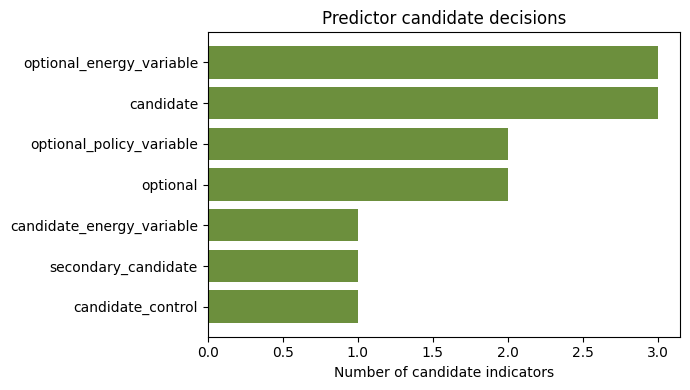

In [12]:
decision_counts = predictor_catalog["include_decision"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(decision_counts.index, decision_counts.values, color="#6c8f3d")
ax.set_title("Predictor candidate decisions")
ax.set_xlabel("Number of candidate indicators")
ax.set_ylabel("")
plt.tight_layout()

leading_predictors = predictor_catalog.loc[
    predictor_catalog["include_decision"].isin(["candidate", "candidate_control", "candidate_energy_variable"]),
    ["variable_concept", "candidate_indicator", "source_variable", "coverage_summary", "decision_reason", "measurement_caveat"],
]
display(leading_predictors.reset_index(drop=True))

## 13. What A Reviewer Should Be Able To See

After candidate discovery, we can make a stronger statement:

> We did not use all available variables, but we systematically screened the relevant target and predictor candidate space before selecting a small interpretable set.

That statement is defensible because the catalogs record:

1. The exact source variable code.
2. The theoretical mechanism.
3. Literature support.
4. Coverage status.
5. Measurement caveats.
6. Inclusion or exclusion rationale.
7. Recommended use, so important non-main variables are not lost.
8. Recommended lag structure to avoid time leakage.

In [13]:
reviewer_fields = pd.DataFrame(
    {
        "catalog": ["target", "predictor"],
        "important_fields": [
            "source_variable, dimension labels, candidate_role, recommended_use, include, reason, coverage columns",
            "variable_concept, source_variable, why_relevant, literature_support, coverage_summary, decision_reason, measurement_caveat, lag_recommendation",
        ],
    }
)
display(reviewer_fields)

,catalog,important_fields
0,target,"source_variable, dimension labels, candidate_role, recommended_use, include, reason, coverage columns"
1,predictor,"variable_concept, source_variable, why_relevant, literature_support, coverage_summary, decision_reason, measurement_..."


## 14. Output Files

These are the files produced by the discovery step. They are committed so the reasoning can be reviewed without rerunning the notebook.

In [14]:
output_files = pd.DataFrame(
    [
        {
            "file": "target_candidate_catalog.csv",
            "what_it_contains": "Systematic OECD patent target search-space screen.",
            "path": required_outputs["targets"],
        },
        {
            "file": "predictor_candidate_catalog.csv",
            "what_it_contains": "Literature- and database-driven predictor candidate screen.",
            "path": required_outputs["predictors"],
        },
        {
            "file": "candidate_discovery_summary.md",
            "what_it_contains": "Human-readable summary of leading candidates and counts.",
            "path": required_outputs["summary"],
        },
    ]
)
output_files["exists"] = output_files["path"].map(lambda path: path.exists())
display(output_files[["file", "exists", "what_it_contains"]])

,file,exists,what_it_contains
0,target_candidate_catalog.csv,True,Systematic OECD patent target search-space screen.
1,predictor_candidate_catalog.csv,True,Literature- and database-driven predictor candidate screen.
2,candidate_discovery_summary.md,True,Human-readable summary of leading candidates and counts.


## 15. Generated Summary

The markdown summary is written by the script so the discovery step can be reviewed without opening this notebook.

In [15]:
summary_path = PROCESSED_DIR / "candidate_discovery_summary.md"
if summary_path.exists():
    display(Markdown(summary_path.read_text(encoding="utf-8")))
else:
    print("Run candidate discovery to generate the markdown summary.")

# Candidate Discovery Summary

This file is generated by `2_data/scripts/candidate_discovery.py`.

The catalogs are reviewer-facing discovery artifacts, not final modeling decisions.

## Target Candidate Counts

| candidate_role | include | candidate_count |
| --- | --- | --- |
| breakdown_candidate | False | 2112 |
| context_only | False | 224 |
| main_target_candidate | True | 1 |
| mechanism_candidate | False | 198 |
| not_suitable | False | 12 |
| secondary_target | False | 140 |
| secondary_target | True | 1 |

## Target Candidate Uses

| candidate_role | recommended_use | include | candidate_count |
| --- | --- | --- | --- |
| breakdown_candidate | diagnostic breakdown candidate | False | 2112 |
| context_only | denominator or context variable | False | 224 |
| main_target_candidate | main outcome candidate | True | 1 |
| mechanism_candidate | mechanism or descriptive candidate | False | 198 |
| not_suitable | do not use without separate justification | False | 12 |
| secondary_target | robustness or thematic outcome candidate | False | 140 |
| secondary_target | robustness outcome candidate | True | 1 |

## Included Or Leading Target Candidates

| source_variable | candidate_role | recommended_use | include | coverage_checked | countries_with_data | first_year | last_year | reason |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| PT_INV.DEV.ENV_PAT._Z | main_target_candidate | main outcome candidate | True | True | 202 | 1990 | 2023 | Preferred normalized target: environment-related technologies as a share of inventions. |
| INV_PS.DEV.ENV_PAT._Z | secondary_target | robustness outcome candidate | True | True | 196 | 1990 | 2023 | Size-normalized patent intensity candidate; useful robustness target. |

## Mechanism Or Descriptive Target Candidates

| source_variable | unit_measure_label | type_label | technology_domain_label | recommended_use | reason |
| --- | --- | --- | --- | --- | --- |
| INV_PS.COL.ADAPT._Z | Inventions per person | International collaboration in development of environment-related technologies | Climate change adaptation technologies | mechanism or descriptive candidate | International collaboration is relevant for mechanisms and descriptive analysis, but it is not the broad country-year innovation outcome for the main target. |
| INV_PS.DIFF.ADAPT._Z | Inventions per person | Diffusion of environment-related technologies | Climate change adaptation technologies | mechanism or descriptive candidate | Diffusion is relevant for adoption and international spread of environmental technologies, but it is analytically different from domestic technology development. |

## Predictor Decision Counts

| include_decision | candidate_count |
| --- | --- |
| candidate | 3 |
| candidate_control | 1 |
| candidate_energy_variable | 1 |
| optional | 2 |
| optional_energy_variable | 3 |
| optional_policy_variable | 2 |
| secondary_candidate | 1 |

## Leading Predictor Candidates

| variable_concept | source | source_variable | include_decision | coverage_summary | decision_reason |
| --- | --- | --- | --- | --- | --- |
| GDP per capita | World Bank WDI | NY.GDP.PCAP.KD | candidate | gdp_per_capita: 213 countries, 35 years, 1990-2024 | Strong coverage and clear interpretation, but may absorb several mechanisms. |
| GDP/population/market size | World Bank WDI | NY.GDP.MKTP.KD; SP.POP.TOTL | candidate_control | gdp: 213 countries, 35 years, 1990-2024; population: 217 countries, 35 years, 1990-2024 | Useful control if the target is not fully size-normalized. |
| R&D expenditure | World Bank WDI | GB.XPD.RSDV.GD.ZS | candidate | rd_expenditure_gdp: 156 countries, 29 years, 1996-2024 | High conceptual fit; coverage is the main constraint. |
| Renewable energy share | World Bank WDI | EG.FEC.RNEW.ZS | candidate_energy_variable | renewable_energy_share: 212 countries, 33 years, 1990-2022 | Prefer at most one energy-system variable in the first small model. |
| Environmental policy stringency | OECD EPS | POL_STRINGENCY.EPS | candidate | eps_index: 40 countries, 31 years, 1990-2020 | Best policy candidate if narrower OECD-style coverage is acceptable. |

## Notes

1. `coverage_checked` only reflects variables present in `data_availability.csv`.
2. Optional World Bank metadata scanning was not enabled for this run.
3. The predictor catalog is provisional because the literature review is still in progress.
4. Final target and predictor choices should be recorded in `0_organization/decision_log.md`.


## 16. What Comes Next

The next data step should not be model fitting yet. It should be a focused panel-building step:

1. Finish the remaining literature review and update the predictor catalog if new concepts or indicators emerge.
2. Choose one main target and one robustness target.
3. Keep mechanism candidates such as collaboration or diffusion for descriptive analysis or later robustness, not as the default outcome.
4. Choose a small predictor set from the leading candidates.
5. Download or verify any deferred predictors, such as RISE or carbon pricing, only if they add clear value.
6. Build a country-year panel.
7. Create lagged predictors, usually `t-1`, before modeling future innovation.

That keeps the project professional: broad enough to avoid arbitrary variable choice, but small enough to stay interpretable.